In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import json

import torch

In [16]:
def calculate_rolling_average(
        data: np.ndarray,
        window_size: int = 10
) -> np.ndarray:
    return np.convolve(np.pad(data, pad_width=int(window_size/2), mode="reflect"), np.ones(window_size)/window_size, mode='valid')[:-1]

In [17]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(np.pi * latitude / 180)

In [18]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [25]:
data_directory = '../m_star_dataset'
dataset_name = 'ePBL_paper_2283_corrected_dz1_nohf'

bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_bl.nc'))
bl_tke_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_tke_bl.nc'))
M_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_M.nc'))
Ekin_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_Ekin.nc'))
Rig_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_Rig_bl.nc'))
u_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_u_surf.nc'))
v_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_v_surf.nc'))
uv_i_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_ekman_filtered_uv_surface.nc'))
NN_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_NN_bl.nc'))
SS_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_SS_bl.nc'))
rho_p_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_rho_p_bl.nc'))
rho_p_surf_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_rho_p_surf.nc'))

with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

In [26]:
rho0 = 1027
g = 9.81
alpha = 2e-4
cp = 4e3

# heat_fluxes = np.array([case['heat_flux'] for case in gotm_case_dict.values()])
coriolis_freqs = np.array([calculate_f(case['lat']) for case in gotm_case_dict.values()])
u_stars = np.array([(case['tx'] / rho0) ** 0.5 for case in gotm_case_dict.values()])
taus = np.array([case['tx'] for case in gotm_case_dict.values()])
grads = np.array([case['temp_grad'] for case in gotm_case_dict.values()])

taus_mask = np.where(taus > 0.005)

# Bs = g * alpha * heat_fluxes / cp

n_cases, t_timesteps = bl_data.bl[taus_mask].values[:,2:].shape

bls = bl_data.bl[taus_mask].values[:,2:].flatten()
tke_bls = -bl_tke_data.bl[taus_mask].values[:,2:].flatten()
bls_im1 = bl_data.bl[taus_mask].values[:,1:-1].flatten()
Ms = M_data.M[taus_mask].values[:,2:].flatten()
Ms_im1 = M_data.M[taus_mask].values[:,1:-1].flatten()
Rig_bl = Rig_bl_data.Rig_bl[taus_mask].values[:,2:].flatten()
SS_bl = SS_data.SS_bl[taus_mask].values[:,2:].flatten()
NN_bl = NN_data.NN_bl[taus_mask].values[:,2:].flatten()
us = u_data.u_surf[taus_mask].values[:,2:].flatten()
vs = v_data.v_surf[taus_mask].values[:,2:].flatten()
u_is, v_is = uv_i_data.u_i[taus_mask].values[:,2:].flatten(), uv_i_data.v_i[taus_mask].values[:,2:].flatten()
Ekins = Ekin_data.Ekin[taus_mask].values[:,2:].flatten()
rho_p_bl = rho_p_bl_data.rho_p_bl[taus_mask].values[:,2:].flatten()
rho_p_surf = rho_p_surf_data.rho_p_surf[taus_mask].values[:,2:].flatten()

coriolis_freqs = np.repeat(coriolis_freqs[taus_mask], t_timesteps)
u_stars = np.repeat(u_stars[taus_mask], t_timesteps)
taus = np.repeat(taus[taus_mask], t_timesteps)
grads = np.repeat(grads[taus_mask], t_timesteps)
# Bs = np.repeat(Bs[taus_mask], t_timesteps)

surface_magnitudes = taus*np.sqrt(us**2+vs**2)
surface_angles = np.arccos(us*taus/(np.sqrt(us**2+vs**2)*taus))
surface_ekin_input = abs(surface_magnitudes*np.cos(surface_angles))

surface_magnitudes_i = taus*np.sqrt(u_is**2+v_is**2)
surface_angles_i = np.arccos(u_is*taus/(np.sqrt(u_is**2+v_is**2)*taus))
surface_ekin_input_i = abs(surface_magnitudes_i*np.cos(surface_angles_i))

(array([40542., 18353., 13154.,  7255.,  3033.,  2130.,   875.,   396.,
          219.,   263.]),
 array([  2.29207325,  38.38285494,  74.47363663, 110.56441832,
        146.6552    , 182.74598169, 218.83676338, 254.92754507,
        291.01832676, 327.10910845, 363.19989014]),
 <BarContainer object of 10 artists>)

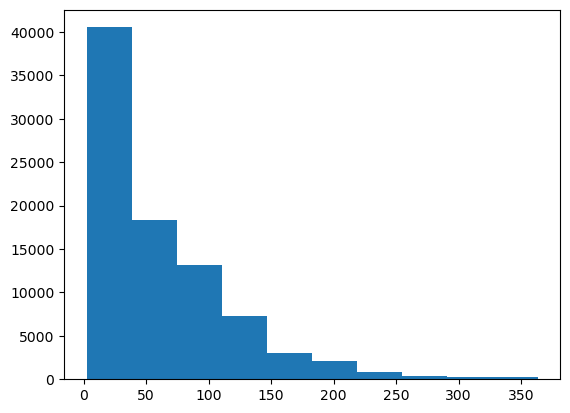

In [30]:
plt.hist(tke_bls)

(array([5193., 4337., 2264., 1585., 1509.,  930.,  486.,  445.,  303.,
         192.]),
 array([996.81011963, 996.84672241, 996.8833252 , 996.91992798,
        996.95653076, 996.99313354, 997.02973633, 997.06633911,
        997.10294189, 997.13954468, 997.17614746]),
 <BarContainer object of 10 artists>)

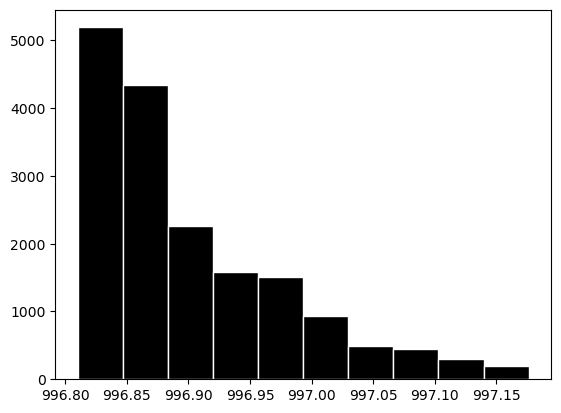

In [16]:
plt.hist(rho_p_surf, color="black", ec="white")

(array([  3555.,  25971., 171490., 390709., 406418., 215835., 115521.,
         46196.,  16541.,   4204.]),
 array([ 1.        ,  2.87484177,  4.74968353,  6.6245253 ,  8.49936706,
        10.37420883, 12.24905059, 14.12389236, 15.99873413, 17.87357589,
        19.74841766]),
 <BarContainer object of 10 artists>)

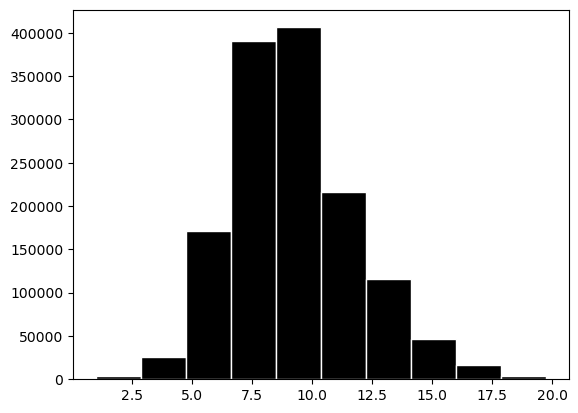

In [31]:
plt.hist(np.sqrt(bls_im1), color="black", ec="white")

(array([ 36879.,  86747.,  42910., 108184., 140572., 187794., 273914.,
        359982., 149140.,  10318.]),
 array([-2.28229657, -2.04875893, -1.81522128, -1.58168364, -1.348146  ,
        -1.11460835, -0.88107071, -0.64753306, -0.41399542, -0.18045778,
         0.05307987]),
 <BarContainer object of 10 artists>)

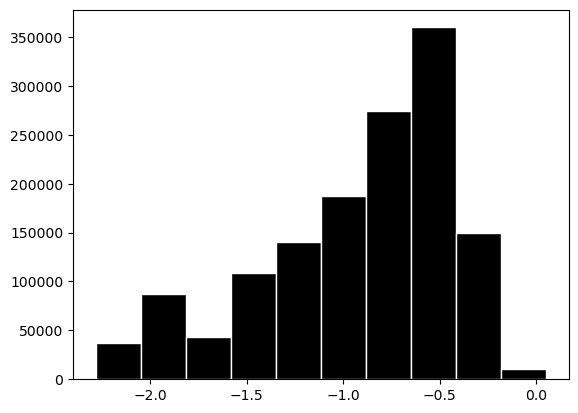

In [32]:
plt.hist(np.log10(surface_magnitudes), color="black", ec="white")

(array([2.00000e+00, 5.00000e+00, 2.50000e+01, 7.40000e+01, 4.87000e+02,
        2.35620e+04, 1.50777e+05, 2.96441e+05, 6.27123e+05, 2.97944e+05]),
 array([-5.53261129, -4.98149942, -4.43038755, -3.87927567, -3.3281638 ,
        -2.77705193, -2.22594006, -1.67482819, -1.12371632, -0.57260444,
        -0.02149257]),
 <BarContainer object of 10 artists>)

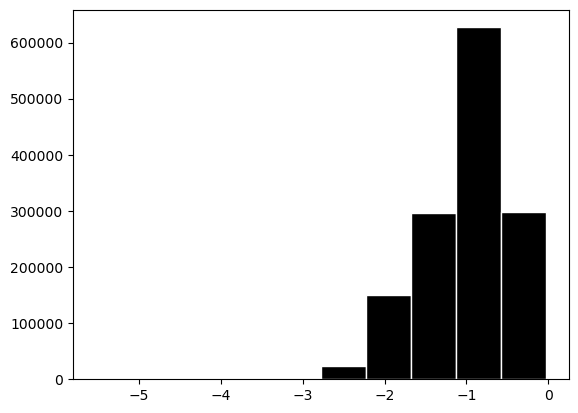

In [33]:
plt.hist(np.log10(surface_ekin_input), color="black", ec="white")

(array([2.50000e+01, 3.49000e+02, 1.89700e+03, 5.80200e+03, 2.05180e+04,
        1.39875e+05, 4.34885e+05, 2.78917e+05, 3.86605e+05, 1.27567e+05]),
 array([-10.05546722,  -9.29047874,  -8.52549027,  -7.76050179,
         -6.99551332,  -6.23052485,  -5.46553637,  -4.7005479 ,
         -3.93555943,  -3.17057095,  -2.40558248]),
 <BarContainer object of 10 artists>)

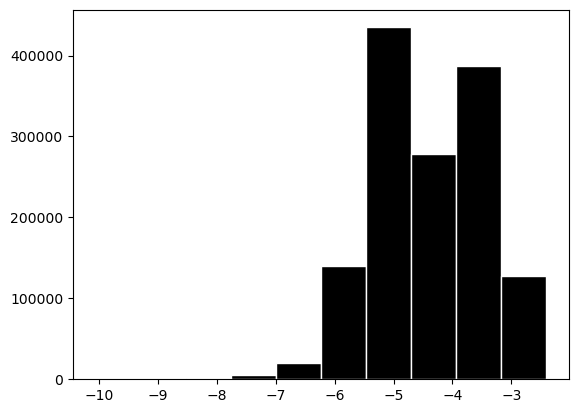

In [34]:
plt.hist(np.log10(SS_bl), color="black", ec="white")

(array([  1896.,   5806.,  60743., 238659., 349855., 385429., 238636.,
         83749.,  27604.,   4063.]),
 array([0.14990901, 0.26245902, 0.37500903, 0.48755903, 0.60010904,
        0.71265905, 0.82520905, 0.93775906, 1.05030907, 1.16285907,
        1.27540908]),
 <BarContainer object of 10 artists>)

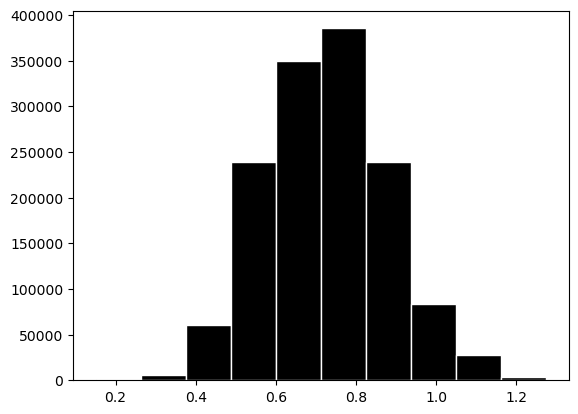

In [35]:
plt.hist(np.sqrt(surface_angles), color="black", ec="white")

In [36]:
# transformations
sqrt_bls = np.sqrt(bls)
sqrt_bls_im1 = np.sqrt(bls_im1)
log_NN_bl = np.log10(NN_bl)
log_SS_bl = np.log10(SS_bl)
sqrt_surface_angles = np.sqrt(surface_angles)
log_surface_ekin_input = np.log10(surface_ekin_input)
log_surface_magnitudes = np.log10(surface_magnitudes)

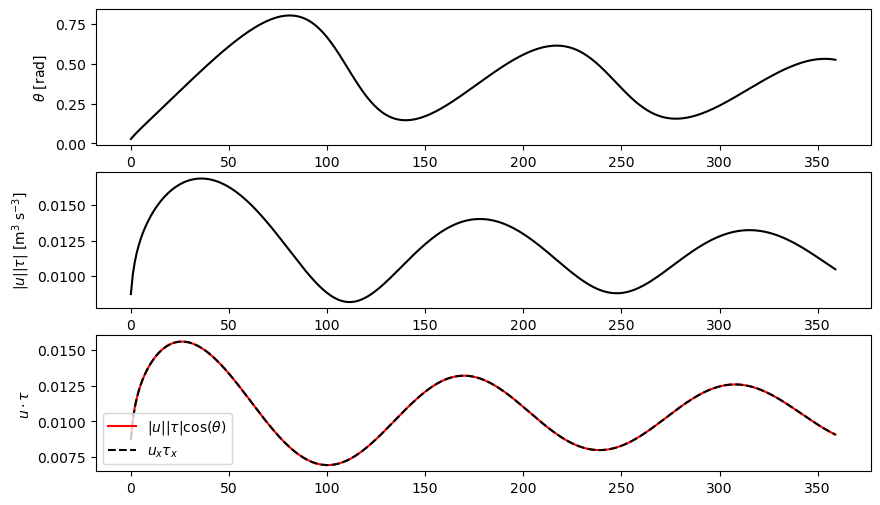

In [21]:
fig, ax = plt.subplots(3,1,figsize=(10,6))

ax[0].set_ylabel(r"$\theta$ [rad]")
ax[0].plot(surface_angles[0:360], color="black")
ax[1].set_ylabel(r"$|u||\tau|$ [m$^3$ s$^{-3}$]")
ax[1].plot(surface_magnitudes[0:360], color="black")
ax[2].set_ylabel(r"$u \cdot \tau$")
ax[2].plot(surface_ekin_input[0:360], color="red", label=r"$|u||\tau|\cos(\theta)$")
ax[2].plot(us[0:360]*taus[0:360], color="black", linestyle="dashed", label=r"$u_x\tau_x$")
ax[2].legend()

In [26]:
# torch_dataset_name = f"{dataset_name}_dataset_M_target_all.pt"
# dataset = torch.tensor(np.array([
#     coriolis_freqs, u_stars, bls, surface_magnitudes, surface_angles, surface_ekin_input, bls_im1,
#     SS_bl, NN_bl, Rig_bl, surface_magnitudes_i, surface_angles_i, surface_ekin_input_i,
#     rho_p_bl, rho_p_surf,
#     Ms
# ]))
torch_dataset_name = f"{dataset_name}_dataset_M_target_bls_grads_and_M_hist.pt"
dataset = torch.tensor(np.array([
    coriolis_freqs, u_stars, bls, tke_bls, grads, Ms_im1,
    Ms
]))
# torch.save(dataset, os.path.join(data_directory, torch_dataset_name))

In [28]:
dataset.shape

torch.Size([7, 86220])

In [27]:
names = [
    "f", "u_star", "bl_rh18", "bl_tke", "grad", "surf_mag", "surf_angle", 
    "u_surf_dot_tau", "bl_rh18_i-1", "SS_bl", "NN_bl", "Rig_bl", "surf_mag_in",
    "surf_angle_in", "u_surf_in_dot_tau", "rho_p_bl", "rho_p_surf", "Ekin", "M_i-1", "M"
    ]

data = [
    coriolis_freqs, u_stars, bls, tke_bls, grads, surface_magnitudes, surface_angles, surface_ekin_input, bls_im1,
    SS_bl, NN_bl, Rig_bl, surface_magnitudes_i, surface_angles_i, surface_ekin_input_i,
    rho_p_bl, rho_p_surf, Ekins, Ms_im1,
    Ms
    ]

In [28]:
data_dict = {name: values for name, values in zip(names, data)}
df = pd.DataFrame(data_dict)
df.to_csv(os.path.join(data_directory, f'{dataset_name}_features_and_targets.csv'), index=False)

In [17]:
pd.read_csv(os.path.join(data_directory, f'{dataset_name}_features_and_targets.csv'))

,f,u_star,bl_rh18,bl_tke,grad,surf_mag,surf_angle,u_surf_dot_tau,bl_rh18_i-1,SS_bl,NN_bl,Rig_bl,surf_mag_in,surf_angle_in,u_surf_in_dot_tau,rho_p_bl,rho_p_surf,Ekin,M_i-1,M
0,0.000025,0.003120,2.900000,3.185877,0.001,0.000355,0.022785,0.000354,1.500000,0.000004,0.000003,18335.255859,0.000315,0.163701,0.000311,996.809998,996.809509,0.252633,1.423252e-09,1.101134e-08
1,0.000025,0.003120,4.200000,4.494191,0.001,0.000399,0.035225,0.000399,2.900000,0.000003,0.000003,17395.074219,0.000360,0.160103,0.000355,996.810364,996.809631,0.437287,1.101134e-08,2.619070e-08
2,0.000025,0.003120,5.400000,5.689848,0.001,0.000429,0.047177,0.000429,4.200000,0.000002,0.000003,16868.216797,0.000391,0.163423,0.000386,996.810669,996.809692,0.631206,2.619070e-08,4.250295e-08
3,0.000025,0.003120,6.500000,6.769360,0.001,0.000453,0.058893,0.000453,5.400000,0.000002,0.000003,16501.744141,0.000415,0.169424,0.000409,996.810974,996.809814,0.834741,4.250295e-08,5.804341e-08
4,0.000025,0.003120,7.500000,7.756600,0.001,0.000473,0.070499,0.000472,6.500000,0.000002,0.000003,15888.974609,0.000436,0.176865,0.000429,996.811218,996.809875,1.047621,5.804341e-08,7.233187e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86215,0.000145,0.031204,91.099998,91.299637,0.040,0.458392,0.287819,0.439536,91.000000,0.001453,0.000484,0.333302,0.404772,0.874909,0.259486,997.583374,997.191650,528.213013,4.183318e-05,4.168140e-05
86216,0.000145,0.031204,91.099998,91.386864,0.040,0.469246,0.253355,0.454266,91.099998,0.001653,0.000557,0.337006,0.405081,0.827198,0.274216,997.581055,997.191895,442.619507,4.168140e-05,4.155352e-05
86217,0.000145,0.031204,91.099998,91.397964,0.040,0.484235,0.227812,0.471723,91.099998,0.001823,0.000618,0.338850,0.411235,0.782349,0.291673,997.578979,997.192078,386.170837,4.155352e-05,4.147545e-05
86218,0.000145,0.031204,91.099998,91.399239,0.040,0.502014,0.212573,0.490714,91.099998,0.001883,0.000652,0.346480,0.422569,0.744869,0.310663,997.577454,997.192261,362.684723,4.147545e-05,4.143826e-05


In [37]:
namelist = ["Ekin", "bl_tke"]
torch.tensor(df[namelist].values.reshape(len(namelist), -1))

tensor([[2.5263e-01, 3.1859e+00, 4.3729e-01,  ..., 1.2710e+02, 4.3982e+02,
         1.2720e+02],
        [2.7874e-01, 2.4988e+00, 5.2050e-01,  ..., 9.1399e+01, 3.7373e+02,
         9.1399e+01]], dtype=torch.float64)

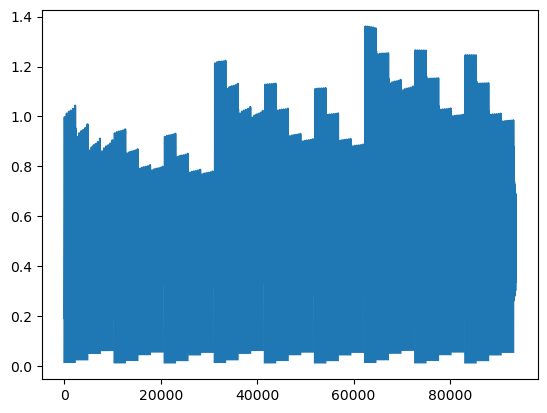

In [52]:
plt.plot(dataset[5,:])